# Regression Trees

* In this exercise, we will explore training, visualizing, and pruning Decision Trees for regression tasks.
* This exercise is based on the `Hitters` dataset discussed in Sec. 8.1 of the ISLP textbook (see page 331).
* The `Hitters` dataset, provided as a `.csv` file contains information about several baseball players

Let's begin by importing
1. The standard libraries: Pandas, Numpy, Pyplot, and Seaborn.
2. From Scikit-Learn: `train_test_split`, `DecisionTreeRegressor`, and `mean_squared_error`

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns



In [2]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor, plot_tree, export_graphviz
from sklearn.metrics import mean_squared_error



Set your Pyplot style to `seaborn-v0_8-bright`

In [3]:
plt.style.use("seaborn-v0_8-bright")

* Read the CSV file into a Pandas DataFrame named `df`
* How many features does the dataset have in total (do not count the `Salary` column here!)? How did you find this information?
* How many datapoints does this dataset have in total?
* How many features have missing entries? How did you find this?

In [7]:
df = pd.read_csv("Hitters.csv")
df.head()

,Unnamed: 0,AtBat,Hits,HmRun,Runs,RBI,Walks,Years,CAtBat,CHits,...,CRuns,CRBI,CWalks,League,Division,PutOuts,Assists,Errors,Salary,NewLeague
0,#NAME?,293,66,1,30,29,14,1,293,66,...,30,29,14,A,E,446,33,20,NaN,A
1,#NAME?,315,81,7,24,38,39,14,3449,835,...,321,414,375,N,W,632,43,10,475.0,N
2,#NAME?,479,130,18,66,72,76,3,1624,457,...,224,266,263,A,W,880,82,14,480.0,A
3,#NAME?,496,141,20,65,78,37,11,5628,1575,...,828,838,354,N,E,200,11,3,500.0,N
4,#NAME?,321,87,10,39,42,30,2,396,101,...,48,46,33,N,E,805,40,4,91.5,N


In [8]:
feature_cols = [c for c in df.columns if c not in ["Salary", "Unnamed: 0"]]
len(feature_cols), feature_cols

(19,
 ['AtBat',
  'Hits',
  'HmRun',
  'Runs',
  'RBI',
  'Walks',
  'Years',
  'CAtBat',
  'CHits',
  'CHmRun',
  'CRuns',
  'CRBI',
  'CWalks',
  'League',
  'Division',
  'PutOuts',
  'Assists',
  'Errors',
  'NewLeague'])

The number of features is found by filtering out the `Salary` column and `Unnamed: 0` column.



In [10]:
len(df)

322

In [12]:
df.isna().sum().sort_values(ascending=False)

,0
Salary,59
AtBat,0
Hits,0
HmRun,0
Unnamed: 0,0
Runs,0
RBI,0
Years,0
Walks,0
CHits,0


None of the features have missing values, only the salary column has missing values. Pandas `.isna` function is used to find this information.

* Set `X` to be the features (we only require the `Years` and `Hits` features here).
* As noted in Sec. 8.1 we set as our regression label the $\log()$ of the salary.
* Reproduce the histograms of `salary` and $\log(salary)$ as shown below.
    * As you can see, computing the logarithm also helps reduce skewness in the `salary` column and the resulting histogram (after transformation) looks closer to a Gaussian.

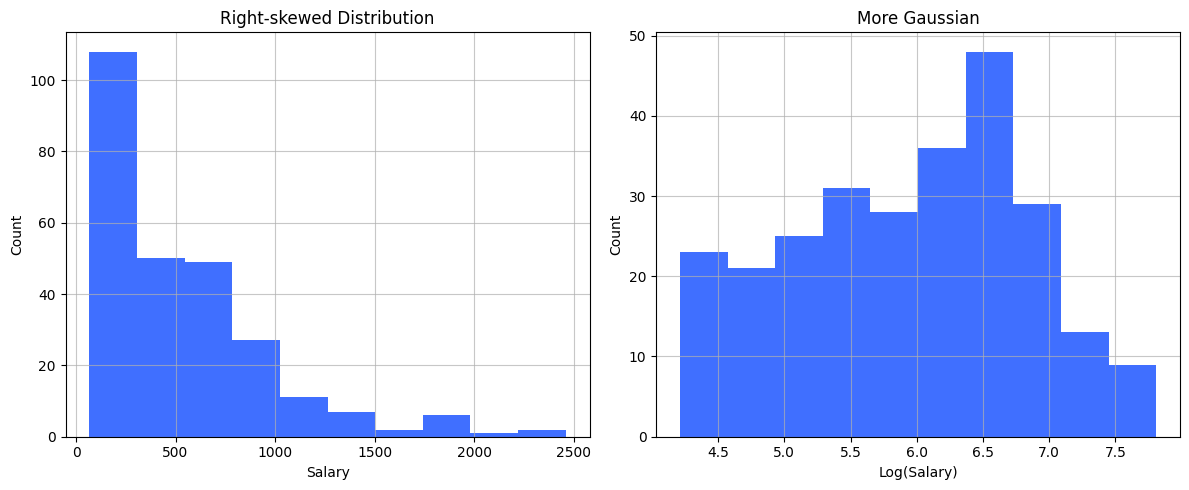

In [32]:
X = df[["Years", "Hits"]]
salary = df["Salary"]
y = np.log(salary)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.histplot(salary, bins=10, edgecolor=None, ax=axes[0])
axes[0].grid(True, alpha=0.7)
axes[0].set_title("Right-skewed Distribution")


sns.histplot(y, bins=10, edgecolor=None, ax=axes[1])
axes[1].grid(True, alpha=0.7)
axes[1].set_title("More Gaussian")
axes[1].set_xlabel("Log(Salary)")

plt.tight_layout()
plt.show()

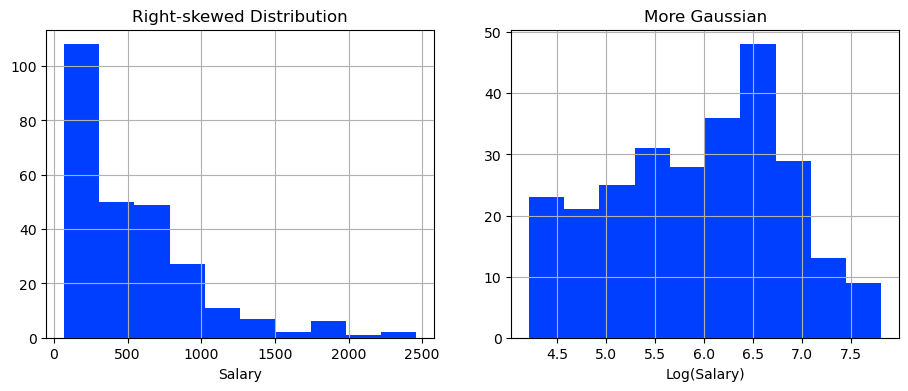

* Fit a tree to all the available data. The tree should have a maximum of `5` leaf nodes (set `random_state=42` for reproducibility).

In [68]:
df_clean = df.dropna(subset=["Salary"]).copy()

X = df_clean[["Years", "Hits"]]
y = np.log(df_clean["Salary"])

tree2 = DecisionTreeRegressor(max_leaf_nodes=5, random_state=42)
tree2.fit(X, y)


DecisionTreeRegressor(max_leaf_nodes=5, random_state=42)

* Using the `export_graphiviz` command, draw the resulting fitted tree (it should look as shown below).
* Information about `export_graphiviz` is available in Chapter 6 of the course textbook (see Fig. 6-1).

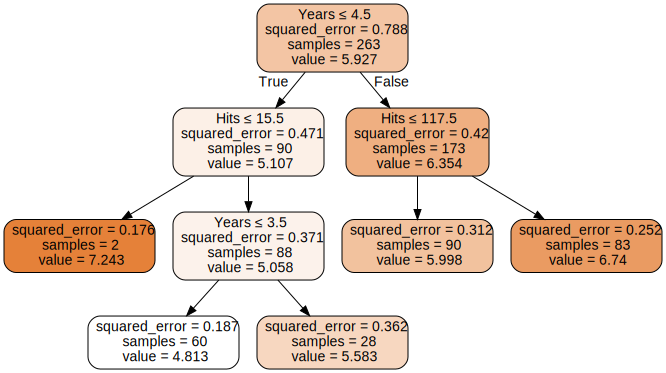

In [71]:
import graphviz
from sklearn.tree import export_graphviz

dot = export_graphviz(
    tree2,
    out_file=None,
    feature_names=["Years", "Hits"],
    filled=True,
    rounded=True,
    special_characters=True
)

graphviz.Source(dot)

* In Pyplot, generate the resulting decision regions.
* Compare the number of `samples` in each leaf node in your fitted tree with the number of data points in each decision region in your plot.

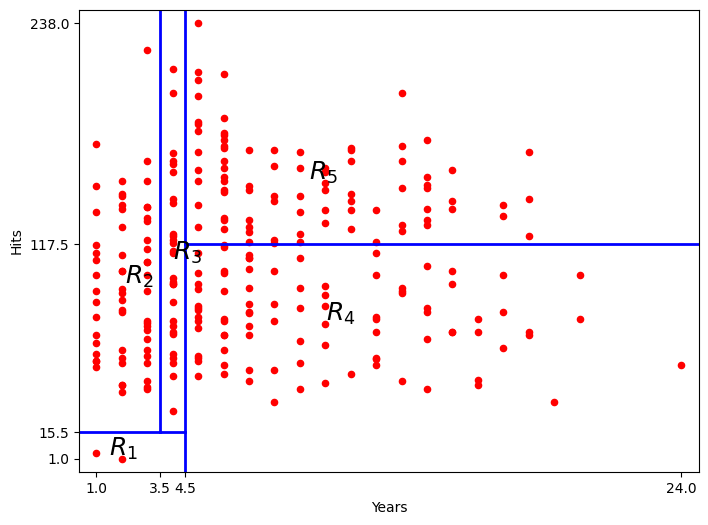

In [55]:
def draw_splits(ax, tree, box):
    t = tree.tree_
    L, R, F, T = t.children_left, t.children_right, t.feature, t.threshold
    def rec(n, xmin, xmax, ymin, ymax):
        if L[n] == -1: return
        thr = T[n]
        if F[n] == 0:
            ax.plot([thr, thr], [ymin, ymax], color="blue", lw=2)
            rec(L[n], xmin, thr, ymin, ymax); rec(R[n], thr, xmax, ymin, ymax)
        else:
            ax.plot([xmin, xmax], [thr, thr], color="blue", lw=2)
            rec(L[n], xmin, xmax, ymin, thr); rec(R[n], xmin, xmax, thr, ymax)
    rec(0, *box)

def label_leaves(ax, tree, X):
    leaf = tree.apply(X)
    lids = np.unique(leaf)
    cents = {l: (X.loc[leaf==l,"Years"].mean(), X.loc[leaf==l,"Hits"].mean()) for l in lids}

    ys = {l:cents[l][1] for l in lids}
    r1, r5 = min(ys, key=ys.get), max(ys, key=ys.get)
    mid = sorted([l for l in lids if l not in (r1,r5)], key=lambda l: cents[l][0])

    lab = {r1:r"$R_1$", r5:r"$R_5$"}
    if len(mid)>0: lab[mid[0]]=r"$R_2$"
    if len(mid)>1: lab[mid[1]]=r"$R_3$"
    if len(mid)>2: lab[mid[2]]=r"$R_4$"

    for l,(x,y) in cents.items():
        if l in lab: ax.text(x, y, lab[l], fontsize=18, fontweight="bold")

xmin, xmax = X2["Years"].min(), X2["Years"].max()
ymin, ymax = X2["Hits"].min(),  X2["Hits"].max()
xpad, ypad = 0.03*(xmax-xmin), 0.03*(ymax-ymin)
box = (xmin-xpad, xmax+xpad, ymin-ypad, ymax+ypad)

fig, ax = plt.subplots(figsize=(8,6))
ax.scatter(X2["Years"], X2["Hits"], s=20, color="red")
ax.set_xlim(box[0], box[1]); ax.set_ylim(box[2], box[3])

draw_splits(ax, tree2, box)
label_leaves(ax, tree2, X2)

ax.set_xticks(xticks)
ax.set_xticklabels([f"{v:.1f}" for v in xticks])
ax.set_yticks(yticks)
ax.set_yticklabels([f"{v:.1f}" for v in yticks])

ax.set_xlabel("Years")
ax.set_ylabel("Hits")

ax.set_xlabel("Years"); ax.set_ylabel("Hits")
plt.show()

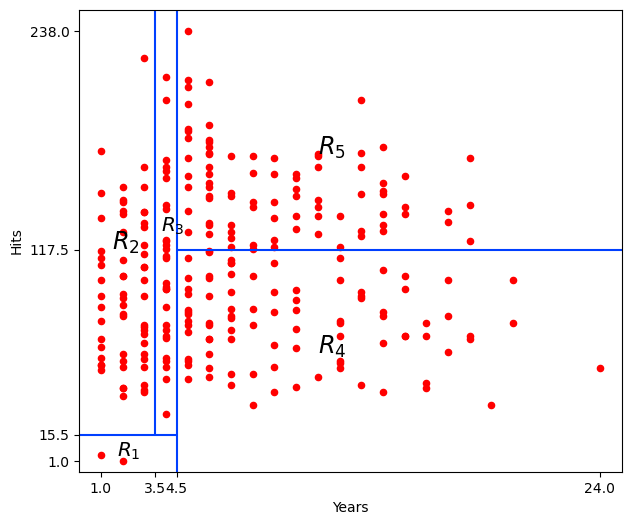

In [56]:
leaf = tree2.apply(X2)

region_counts = {l:int((leaf==l).sum()) for l in np.unique(leaf)}

t = tree2.tree_
leaf_nodes = np.where(t.children_left == -1)[0]
tree_counts = {n:int(t.n_node_samples[n]) for n in leaf_nodes}

region_counts, tree_counts

({np.int64(3): 90,
  np.int64(4): 83,
  np.int64(5): 2,
  np.int64(7): 60,
  np.int64(8): 28},
 {np.int64(3): 90,
  np.int64(4): 83,
  np.int64(5): 2,
  np.int64(7): 60,
  np.int64(8): 28})

* Using Scikit-Learn's built-in `plot_tree()` method, reproduce the decision tree below.
* `export_graphiviz` is usually a better option for visualization.

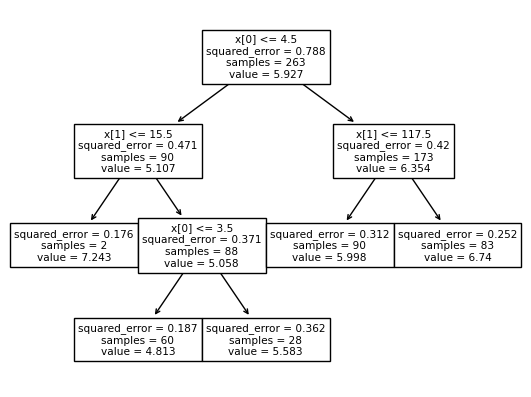

In [66]:
fig, ax = plt.subplots(figsize=(6.6, 4.9))

texts = plot_tree(
    tree2,
    filled=False,
    rounded=False,
    impurity=True,
    proportion=False,
    precision=3,
    ax=ax
)

for t in texts:
    if t.get_text().strip() in ("True", "False"):
        t.set_text("")

plt.show()

[Text(0.5, 0.875, 'x[0] <= 4.5\nsquared_error = 0.788\nsamples = 263\nvalue = 5.927'),
 Text(0.25, 0.625, 'x[1] <= 15.5\nsquared_error = 0.471\nsamples = 90\nvalue = 5.107'),
 Text(0.125, 0.375, 'squared_error = 0.176\nsamples = 2\nvalue = 7.243'),
 Text(0.375, 0.375, 'x[0] <= 3.5\nsquared_error = 0.371\nsamples = 88\nvalue = 5.058'),
 Text(0.25, 0.125, 'squared_error = 0.187\nsamples = 60\nvalue = 4.813'),
 Text(0.5, 0.125, 'squared_error = 0.362\nsamples = 28\nvalue = 5.583'),
 Text(0.75, 0.625, 'x[1] <= 117.5\nsquared_error = 0.42\nsamples = 173\nvalue = 6.354'),
 Text(0.625, 0.375, 'squared_error = 0.312\nsamples = 90\nvalue = 5.998'),
 Text(0.875, 0.375, 'squared_error = 0.252\nsamples = 83\nvalue = 6.74')]

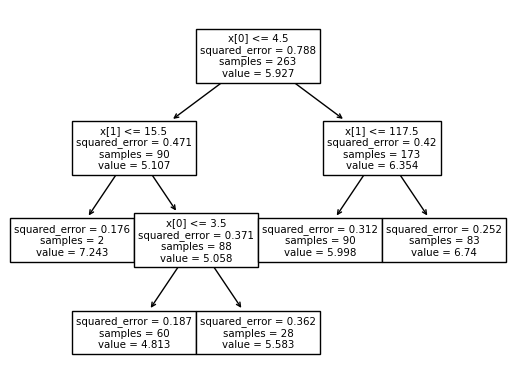

## **Cost-complexity pruning**
We will now try to find the optimal tree using **cost_complexity pruning**
1. Split the data into a training set and a testing set (technically, this is for validation). Use `test_size=0.3`, and `random_state=42`.
   * What are the sizes of the training and testing feature sets?
2. Train a full-sized Decision Tree using all the available data.
3. Once again, visualize the tree using `export_graphviz.`
4. Does it look like this tree is overfitting to $\mathcal{D}_{train}$? If yes, what suggests this? If no, why not?

In [80]:
X = df_clean[["Years", "Hits"]]
y = np.log(df_clean["Salary"])

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42
)

X_train.shape, X_test.shape

((184, 2), (79, 2))

In [73]:
tree_full = DecisionTreeRegressor(random_state=42)
tree_full.fit(X_train, y_train)

DecisionTreeRegressor(random_state=42)

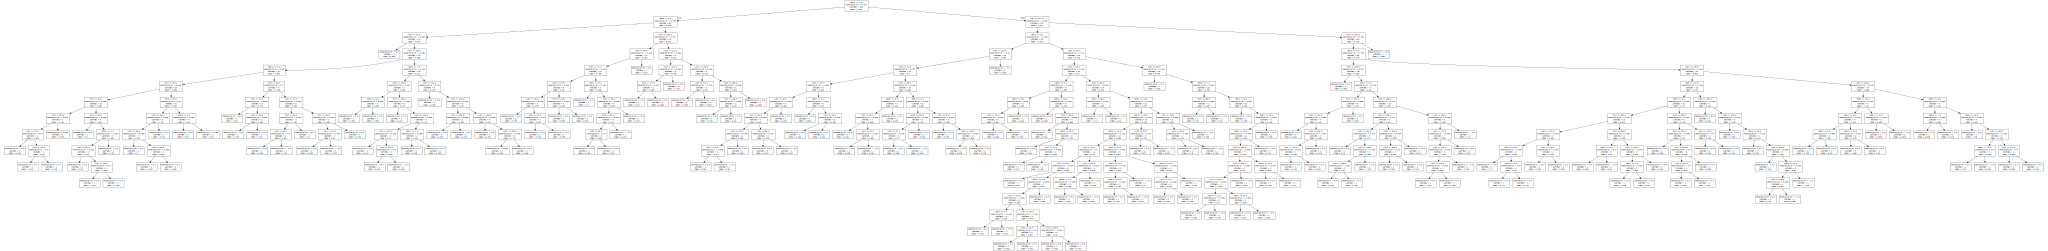

In [74]:
dot = export_graphviz(
    tree_full,
    out_file=None,
    feature_names=["Years", "Hits"],
    filled=False,
    rounded=False,
    impurity=True
)

graphviz.Source(dot)

In [75]:
print("Depth:", tree_full.get_depth())
print("Leaves:", tree_full.get_n_leaves())
print("Train R^2:", tree_full.score(X_train, y_train))
print("Test  R^2:", tree_full.score(X_test, y_test))

Depth: 15
Leaves: 178
Train R^2: 0.9983827606953871
Test  R^2: 0.382281048498768


Yes, the full-sized decision tree appears to be overfitting to the training data (Dtrain). The visualization shows a very deep and complex tree with many splits, resulting in a large number of leaf nodes that partition the training data into very small regions. This high level of complexity suggests that the model is closely fitting noise and minor variations in the training set rather than capturing the underlying relationship between the predictors and the response. This is further supported by the fact that the model achieves nearly perfect performance on the training data while performing significantly worse on the test data, which is a classic indicator of overfitting.

## **Regularized Loss**
We will now find the optimal tree using the **regularized loss**: $R_{\alpha}(T) = R(T)+\alpha |T|$
1. Your full-sized tree has an associated method named `cost_complexity_pruning_path()`. What does this method do?
2. Use the `ccp_alphas` attribute to create a list called `ccp_alphas` containing values of the regularization coefficient. What is the size of you list of the regularization coefficients?
3. Running `cost_complexity_pruning_path()` also gives the total leaf impurity in tree $T_{\alpha}$. Generate the total leaf impurity vs $\alpha$. Your plot should look like the one below.
4. Explain the trend of this plot.

cost_complexity_pruning_path(X, y) computes the sequence of weakest-link prunings for your fitted tree. Concretely, it returns:
ccp_alphas: the regularization strengths
𝛼 at which the optimal subtree changes
impurities: the corresponding total leaf impurity of the subtree
𝑇𝛼 (for regression trees this is based on squared error)

In [81]:
path = tree_full.cost_complexity_pruning_path(X_train, y_train)

ccp_alphas = list(path.ccp_alphas)
impurities = path.impurities

print("Number of alphas:", len(ccp_alphas))

Number of alphas: 137


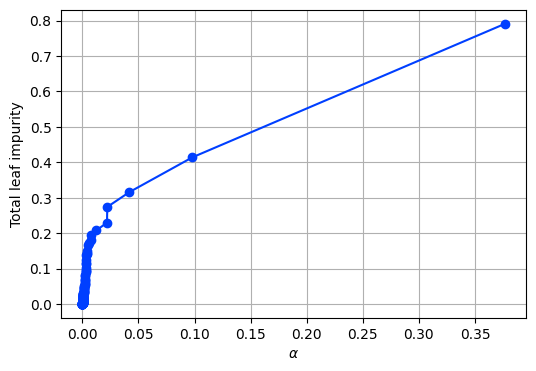

In [82]:
plt.figure(figsize=(6,4))
plt.plot(ccp_alphas, impurities, marker="o")
plt.xlabel(r"$\alpha$")
plt.ylabel("Total leaf impurity")
plt.grid(True)
plt.show()

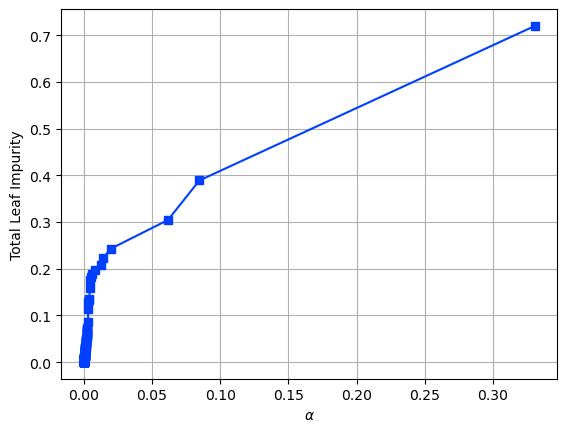

As 𝛼 increases, the cost-complexity penalty
𝛼∣𝑇∣ places a stronger cost on having many leaves, so the optimal subtree 𝑇𝛼 becomes progressively smaller (more aggressively pruned). When the tree is pruned, it has fewer leaves and therefore fits the training data less precisely, which causes the total leaf impurity (training error within leaves) to increase or stay the same.

1. For each value of $\alpha$ in the list `ccp_alphas` train a decision tree regressor. Store all the trees in a list.
2. How many nodes does the last tree have? What value of $\alpha$ does this correspond to?

In [83]:
ccp_alphas = path.ccp_alphas

trees = []
for a in ccp_alphas:
    t = DecisionTreeRegressor(random_state=42, ccp_alpha=a)
    t.fit(X_train, y_train)
    trees.append(t)


In [84]:
last_tree = trees[-1]
last_alpha = ccp_alphas[-1]

num_nodes_last = last_tree.tree_.node_count

print("Last alpha:", last_alpha)
print("Nodes in last tree:", num_nodes_last)
print("Leaves in last tree:", last_tree.get_n_leaves())

Last alpha: 0.37688031266748695
Nodes in last tree: 1
Leaves in last tree: 1


* Use the `score()` method associated with your trees to generate two lists: train and test accuracy for each value of $\alpha.$
* Plot train and test accuracy vs $\alpha.$
* Which value of $\alpha$ would you choose? Why?

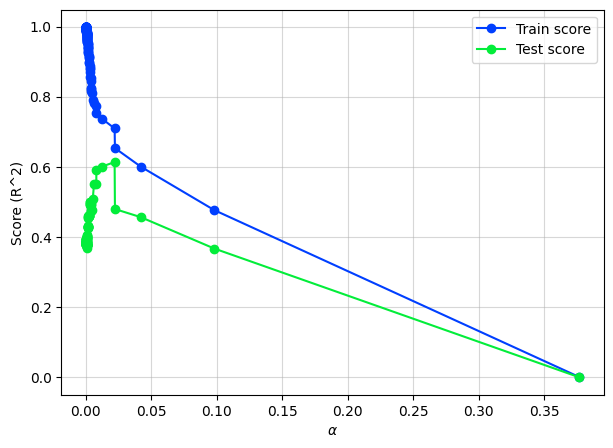

In [88]:
train_scores = []
test_scores = []

for t in trees:
    train_scores.append(t.score(X_train, y_train))
    test_scores.append(t.score(X_test, y_test))

plt.figure(figsize=(7,5))
plt.plot(ccp_alphas, train_scores, marker="o", label="Train score")
plt.plot(ccp_alphas, test_scores, marker="o", label="Test score")
plt.xlabel(r"$\alpha$")
plt.ylabel("Accuracy")
plt.grid(True, alpha=0.5)
plt.legend()
plt.show()

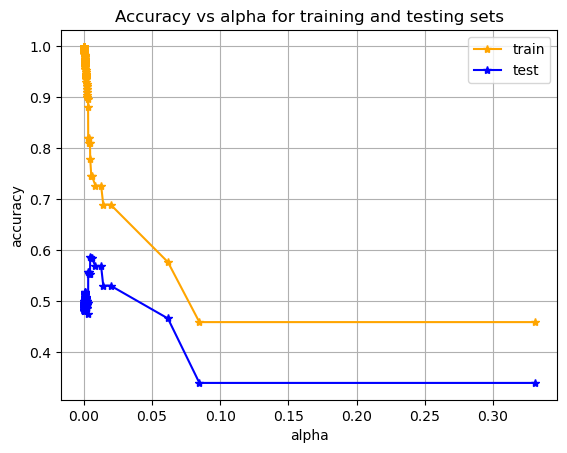

* Let's call this value $\alpha^*.$ How many leaves does $T_{\alpha^*}$ have?
* Draw $T_{\alpha^*}$
* What is the reduction in the number of leaves in the full tree versus the optimal regularized tree?

In [89]:
best_idx = np.argmax(test_scores)
alpha_star = ccp_alphas[best_idx]

alpha_star

np.float64(0.021916384550570198)

In [90]:
T_alpha_star = trees[best_idx]

num_leaves_alpha_star = T_alpha_star.get_n_leaves()
num_leaves_alpha_star

np.int64(6)

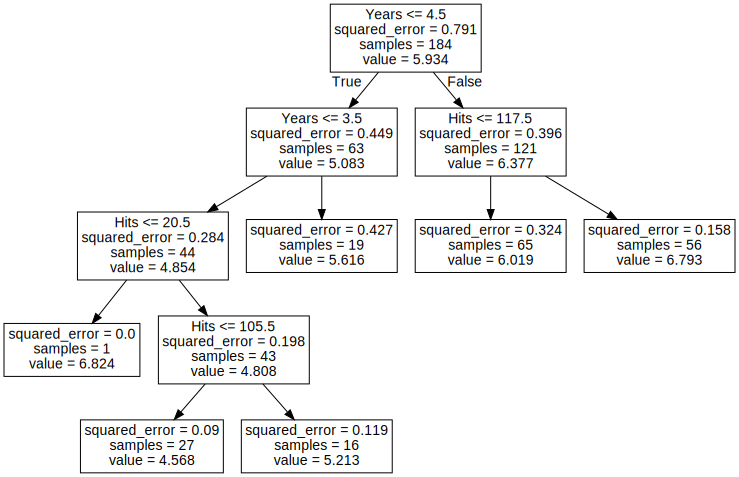

In [91]:
dot = export_graphviz(
    T_alpha_star,
    out_file=None,
    feature_names=["Years", "Hits"],
    filled=False,
    rounded=False,
    impurity=True
)

graphviz.Source(dot)

In [92]:
full_tree_leaves = tree_full.get_n_leaves()
full_tree_leaves
reduction = full_tree_leaves - num_leaves_alpha_star
reduction

np.int64(172)